In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [8]:
df = pd.read_csv("Dry_Bean.xls")

In [9]:
df
########  KARAR AGACI

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [10]:
df.isnull()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13607,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13608,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13609,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df["Class"].value_counts()

DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: Class, dtype: int64

In [12]:
df["Class"]=df["Class"].map({
    "DERMASON":0,
    "SIRA":1,
    "SEKER":2,
    "HOROZ":3,
    "CALI":4,
    "BARBUNYA":5,
    "BOMBAY":6    
})
df

##kategorık sutunu sayısal yaptık

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,2
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,2
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,2
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,2
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,0
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,0
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,0
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,0


In [68]:
X = df.drop(["Class","Extent","Solidity"],axis = 1)
Y = df["Class"]

##bagımlı bagımsız degıskene ayrıma 

In [69]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [70]:
##model olusturma 

model = DecisionTreeClassifier(max_depth=5)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [71]:
y_pred= model.predict(x_test)    ##tAHMİN YAPTIR

In [72]:
dogruluk = accuracy_score(y_pred,y_test)
dogruluk

0.8780756518545721

In [73]:
siniflandırma_raporu = classification_report(y_test,y_pred)
print(siniflandırma_raporu)

##basarı oranları

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       671
           1       0.83      0.88      0.86       536
           2       0.97      0.90      0.94       413
           3       0.99      0.88      0.93       408
           4       0.72      0.90      0.80       317
           5       0.84      0.64      0.73       261
           6       1.00      1.00      1.00       117

    accuracy                           0.88      2723
   macro avg       0.89      0.87      0.88      2723
weighted avg       0.88      0.88      0.88      2723



In [74]:
con_matris =confusion_matrix(y_pred,y_test)

In [75]:
con_matris

array([[621,  54,  22,   7,   0,   0,   0],
       [ 44, 470,  15,  18,   1,  15,   0],
       [  6,   5, 373,   0,   0,   0,   0],
       [  0,   1,   0, 357,   2,   0,   0],
       [  0,   6,   0,  25, 285,  78,   0],
       [  0,   0,   3,   1,  29, 168,   0],
       [  0,   0,   0,   0,   0,   0, 117]], dtype=int64)

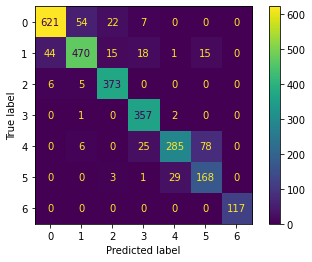

In [76]:
##gorsellestırma
con_matris_gorsel = ConfusionMatrixDisplay(con_matris, display_labels=sorted(y_train.unique()))
con_matris_gorsel.plot()


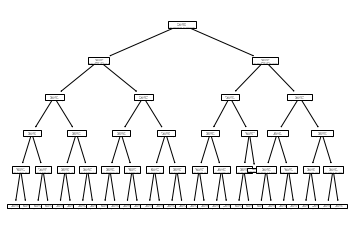

In [77]:
plot_tree(model);    ##karar agacına model = DecisionTreeClassifier(max_depth=5) kısmında derınlık katarız ve kısıtlarız

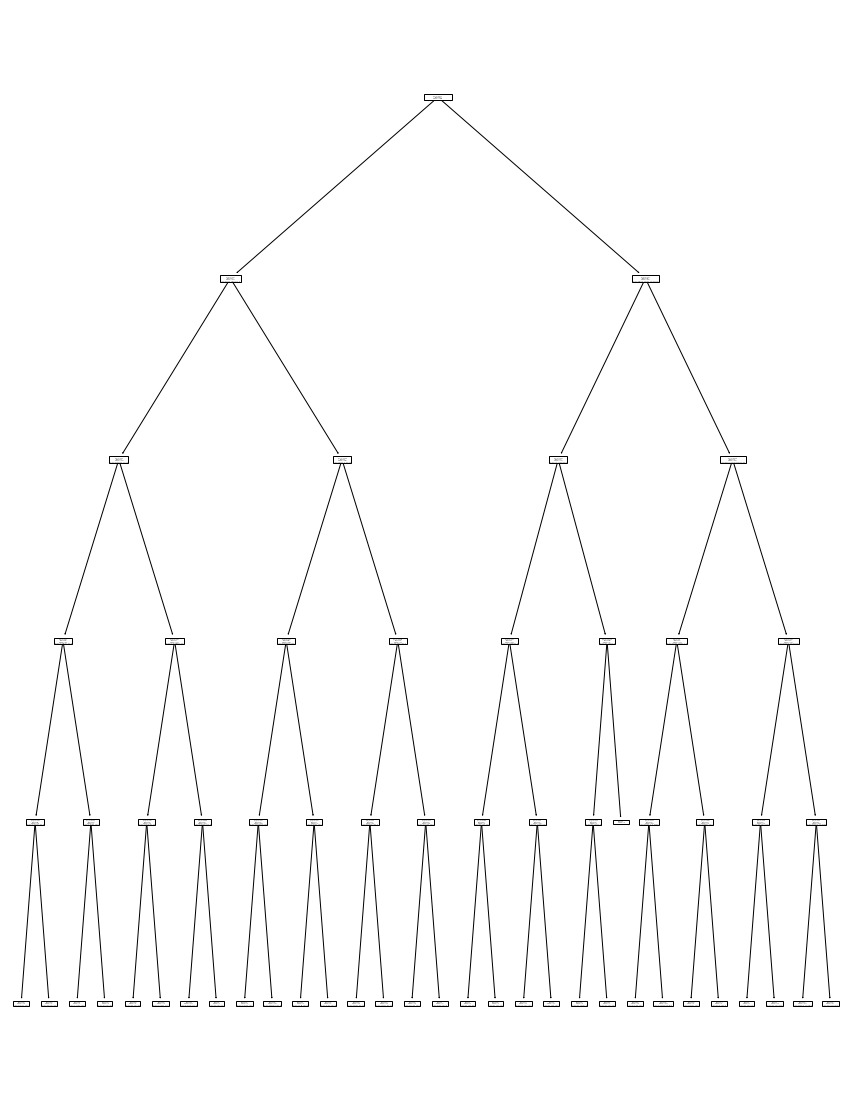

In [78]:
plt.figure(figsize=(15,20))   ##derinlik kattıktan sonra bu kısmım ıle ksııtlarız 
plot_tree(model);

In [79]:
## rasgele agac uretme 

In [80]:
r_model = RandomForestClassifier(
         n_estimators=100,
         max_depth=7
)
r_model.fit(x_train,y_train)

RandomForestClassifier(max_depth=7)

In [81]:
r_pred = r_model.predict(x_test)

In [82]:
r_dogruluk = accuracy_score(r_pred,y_test)
r_dogruluk

0.9070877708409842

In [83]:
rf_rapor=classification_report(r_pred ,y_test)
print(rf_rapor)

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       680
           1       0.88      0.85      0.87       555
           2       0.93      0.96      0.94       403
           3       0.95      0.97      0.96       398
           4       0.89      0.87      0.88       323
           5       0.82      0.86      0.84       247
           6       1.00      1.00      1.00       117

    accuracy                           0.91      2723
   macro avg       0.91      0.92      0.91      2723
weighted avg       0.91      0.91      0.91      2723



In [84]:
onem_dereceleri = r_model.feature_importances_
onem_dereceleri

array([0.05341692, 0.09198247, 0.08854748, 0.07050004, 0.07933181,
       0.0580095 , 0.09527714, 0.07133193, 0.03527305, 0.09340982,
       0.09592459, 0.04713189, 0.10438114, 0.01548223])

<BarContainer object of 14 artists>

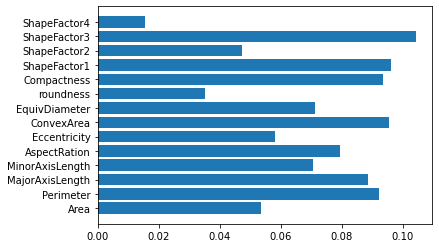

In [85]:
plt.barh(X.columns,onem_dereceleri)